# Diagnostics of QDM bias-correction 

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import os
import re
import glob
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
from matplotlib import lines as mlines
import matplotlib as mpl
import string
from cartopy import crs as ccrs
import cmocean
from scipy import stats as sstats

from funcs_support import get_params,get_filepaths, area_mean, utility_print
from funcs_aux import (utility_save, _verify_file_rows, _create_filenames, 
                       _restore_doys, extract_gwl, repeat_ds, get_landmask)

dir_list = get_params()

In [2]:
dfr = get_filepaths(source_dir = 'raw')
dfp = get_filepaths(source_dir = 'proc')

In [3]:
df_proc = dfp.query(f'varname == "tas" and proj_method == "QDM"')
df_proc = df_proc.reset_index().drop('index',axis=1)
df_proc = df_proc.set_index(['model','exp','run','proj_base']).sort_index()

In [4]:
from distributed import Client
# Start dask client
client = Client()
display(client)

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/schwarzwald/bcd_me_proc2/proxy/8787/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/schwarzwald/bcd_me_proc2/proxy/8787/status,Workers: 6
Total threads: 18,Total memory: 72.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35067,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/schwarzwald/bcd_me_proc2/proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:36331,Total threads: 3
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/schwarzwald/bcd_me_proc2/proxy/34553/status,Memory: 12.00 GiB
Nanny: tcp://127.0.0.1:33875,


## Testing QDM at each location
### Get K-S tests of CDFs at each location for each model / ensemble / run

(MIROC, MPI, MRI are the three models that were still processing over to `bcd_me/` storage when I pressed go on this at 8:10PM on 02/14)

In [5]:
var = 'tas'

# Load reanalysis
params_proc = {'wwidth':31,'nqs':100,'mod_rea':'ERA5-025'}
mod_reas = ['ERA5-025','MERRA2','JRA-3Q','GMFD']
ds_rea = xr.concat([xr.open_dataset(dfp.query(f'model == "{mod_rea}" and suffix == "RESHAPE" and varname == "{var}"').iloc[0]['path'])
                    for mod_rea in mod_reas],
                   dim=pd.Index([re.sub(r'\-025','',m) for m in mod_reas],name='proj_base'))


ds_rea = _restore_doys(ds_rea, params_proc)
ds_rea['year'] = np.arange(1,21)

ds_rea = ds_rea.chunk({'lat':50,'lon':50,'dayofyear':-1,'year':-1,'proj_base':1}).unify_chunks()

In [6]:
def wrapper_kstest(da1,da2):

    def kstest(x1,x2):
        ks = sstats.kstest(x1.flatten(),x2.flatten()
                        )
        pval = ks.pvalue
    
        return pval
    pvals = xr.apply_ufunc(kstest,
                            da1.load(),
                            da2.load(),
                            input_core_dims = [['dayofyear','year'],['dayofyear','year']],
                            vectorize=True
                          )
    return pvals

In [7]:
modlist = [re.split(r'\.',re.split(r'\_',re.split(r'\/',fn)[-1])[3])[0] for fn in np.sort(glob.glob(f'/glade/campaign/cgd/cas/schwarzwald/bcd_me/bcd_me_qdm_*.zarr'))]
load_fns = []
overwrite = False
for mod in tqdm(modlist):
    output_fn = f'{dir_list['aux_bigmem']}diagnostics/kstests_{mod}_GWL0.61_vsrea.zarr'
    load_fns.append(output_fn)
    if overwrite or not os.path.exists(output_fn):
        ds_mod = xr.open_zarr(f'/glade/campaign/cgd/cas/schwarzwald/bcd_me/bcd_me_qdm_{mod}.zarr',decode_timedelta=False)
        ds_mod = ds_mod.sel(gwl=0.61)
        ds_mod = ds_mod.chunk({'lat':50,'lon':50}).unify_chunks()
        ds_mod = ds_mod.sel(proj_base = [mod for mod in ds_mod.proj_base.values if mod != "PRISM"])
    
        ks_out = xr.map_blocks(func = wrapper_kstest,
                  obj = ds_mod.tas.drop_vars(['calendar_year','gwl']),
                  args = (ds_rea.tas.sel(proj_base = ds_mod.proj_base.values),),
                  template=ds_mod.tas.isel(dayofyear=0,year=0,drop=True).drop_vars(['calendar_year','gwl']))

        ks_out.attrs = {'SOURCE':'bcd_me_diagnostics.ipynb',
                    'DESCRIPTION':'ks tests at each location between ESM runs and reanalysis, at GWL0.61 (H0 = same distribution)'}

        utility_save(ks_out.drop_encoding(),output_fn,zarr_mode = 'w')
    else:
        print(output_fn+' exists, skipped!')

  0%|          | 0/12 [00:00<?, ?it/s]

/glade/derecho/scratch/schwarzwald/bcd_me_aux/diagnostics/kstests_ACCESS-ESM1-5_GWL0.61_vsrea.zarr exists, skipped!
/glade/derecho/scratch/schwarzwald/bcd_me_aux/diagnostics/kstests_CESM2-WACCM_GWL0.61_vsrea.zarr exists, skipped!
/glade/derecho/scratch/schwarzwald/bcd_me_aux/diagnostics/kstests_CNRM-CM6-1_GWL0.61_vsrea.zarr exists, skipped!
/glade/derecho/scratch/schwarzwald/bcd_me_aux/diagnostics/kstests_CNRM-ESM2-1_GWL0.61_vsrea.zarr exists, skipped!
/glade/derecho/scratch/schwarzwald/bcd_me_aux/diagnostics/kstests_CanESM5_GWL0.61_vsrea.zarr exists, skipped!
/glade/derecho/scratch/schwarzwald/bcd_me_aux/diagnostics/kstests_EC-Earth3-Veg_GWL0.61_vsrea.zarr exists, skipped!
/glade/derecho/scratch/schwarzwald/bcd_me_aux/diagnostics/kstests_EC-Earth3_GWL0.61_vsrea.zarr exists, skipped!
/glade/derecho/scratch/schwarzwald/bcd_me_aux/diagnostics/kstests_FGOALS-g3_GWL0.61_vsrea.zarr exists, skipped!
/glade/derecho/scratch/schwarzwald/bcd_me_aux/diagnostics/kstests_IPSL-CM6A-LR_GWL0.61_vsrea.

### Diagnose K-S tests

In [8]:
# Load K-S p-values
pvals_all = []
for fn in load_fns:
    d = xr.open_zarr(fn)
    d = d.assign_coords({'model':(('idv'),[re.split(r'\_',re.split(r'\/',fn)[-1])[1]]*d.sizes['idv'])})
    d = d.set_index(idv = ['model','experiment','run'])
    pvals_all.append(d.load())
pvals_all = xr.concat(pvals_all,dim='idv')

In [9]:
# Get 0.01 quantile of pvalues across ESM runs 
q01 = pvals_all.quantile(0.01,dim='idv')

/glade/u/home/schwarzwald/.conda/envs/bcd_me/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1617: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [11]:
# Get landmask for GMFD
landmask = get_landmask(q01)

lat/lon bounds not found in dataset; they will be created.


In [13]:
base_cmap = cmocean.cm.amp_r
x = 0.05  # bottom fraction

# Sample the original colormap
n = 256
colors = base_cmap(np.linspace(0, 1, n))

# Choose replacement color (RGBA)
low_color = mpl.colors.to_rgba('tab:purple')

# Replace bottom X fraction
n_low = int(x * n)
colors[:n_low, :] = low_color

# New colormap
cmap_mod = mpl.colors.ListedColormap(colors)

/glade/u/home/schwarzwald/projects/bcd_me_final/aux_data/diagnostics/ks-pvals-min_diag_byrea_figure.pdf saved!
/glade/u/home/schwarzwald/projects/bcd_me_final/aux_data/diagnostics/ks-pvals-min_diag_byrea_figure.png saved!


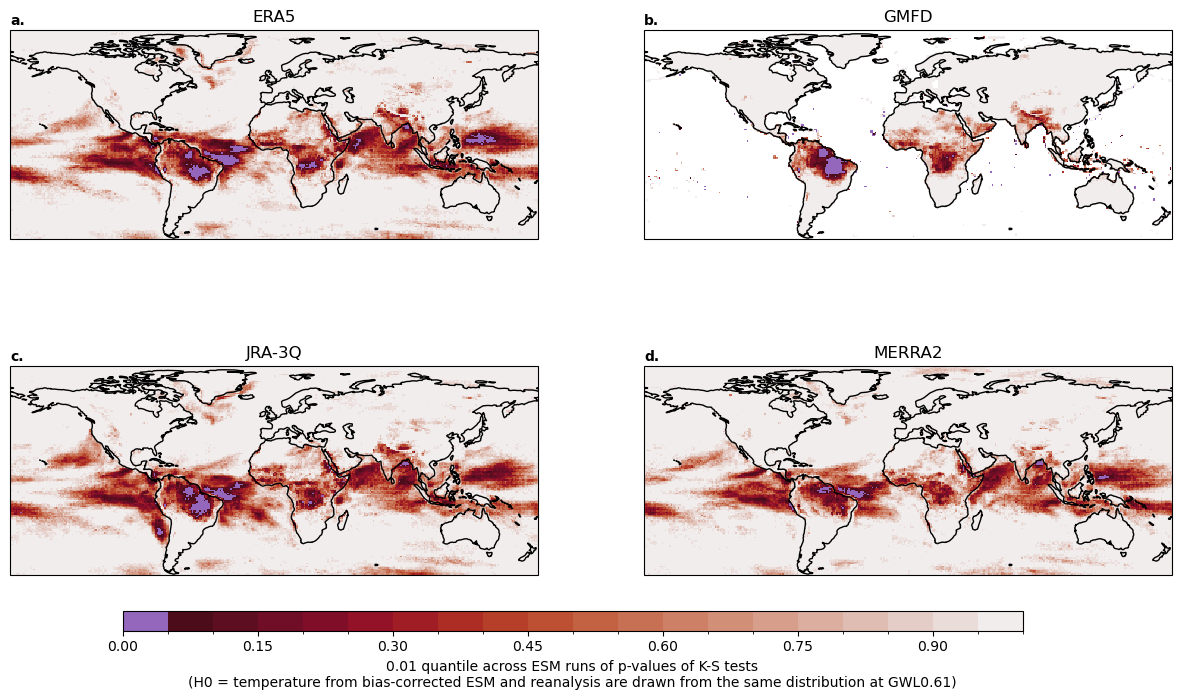

In [14]:
save_fig = True
output_fn = f'{dir_list['aux']}diagnostics/ks-pvals-min_diag_byrea_figure'

fig = plt.figure(figsize=(15,8))

# With cbar_params syntax
cbar_params = {'vmin':0,'vmax':1,
               'cmap':cmap_mod,'levels':21}
clabel = '0.01 quantile across ESM runs of p-values of K-S tests\n(H0 = temperature from bias-corrected ESM and reanalysis are drawn from the same distribution at GWL0.61)'

for plt_idx,mod_rea in enumerate(q01.proj_base.values):
    ax = plt.subplot(2,2,plt_idx+1,projection=ccrs.PlateCarree())

    plot_data = q01.tas.sel(proj_base = mod_rea)

    if mod_rea == 'GMFD':
        plot_data = plot_data.where(landmask)
    plot_data.plot(**cbar_params,add_colorbar=False)

    ax.coastlines()

    ax.set_title(re.sub(r'\-025','',mod_rea))

    ax.annotate(string.ascii_lowercase[plt_idx]+'.',(0,1.025),xycoords = 'axes fraction',
                fontweight='bold')

cax = fig.add_axes([0.2,0.085,0.6,0.025])

#plt.tight_layout()

# Vertical colorbar
if 'levels' in cbar_params:
    levels = mpl.ticker.MaxNLocator(nbins=cbar_params['levels']).tick_values(cbar_params['vmin'],cbar_params['vmax'])
    norm = mpl.colors.BoundaryNorm(levels, ncolors=cbar_params['cmap'].N, clip=True)
else:
    norm = mpl.colors.Normalize(vmin=cbar_params['vmin'],vmax=cbar_params['vmax'])
sm = plt.cm.ScalarMappable(cmap=cbar_params['cmap'],norm=norm)
plt.colorbar(sm,cax=cax,label=clabel,orientation='horizontal')

if save_fig:
    utility_print(output_fn)

In [123]:
lowest_fit_mod = pvals_all.sel(proj_base='ERA5').where((pvals_all.sel(proj_base = 'ERA5')>0).all(('lat','lon')),drop=True)
lowest_fit_mod = lowest_fit_mod.idv.values[area_mean(lowest_fit_mod.where((lowest_fit_mod > 0.000001).all(('lat','lon')),drop=True).tas).argmin()]

In [18]:
def ecdf(x):
        x = np.sort(x)
        y = np.arange(1, len(x) + 1) / len(x)
        return x, y

In [19]:
def plot_cdf(x1,x2,ax=None):
    if ax is None:
        ax = plt.subplot()
    def ecdf(x):
        x = np.sort(x)
        y = np.arange(1, len(x) + 1) / len(x)
        return x, y

    x1 = x1.values.flatten()
    x2 = x2.values.flatten()
    x1s, y1 = ecdf(x1)
    x2s, y2 = ecdf(x2)

    ax.plot(x1s, y1, lw=1, alpha=0.7, label='ESM run',color='tab:blue')
    ax.plot(x2s, y2, lw=1, alpha=0.7, label=re.sub(r'\-025','',params_proc['mod_rea']),color='k',linestyle='--')


In [124]:
lowest_fit_mod

('CanESM5', 'ssp245', 'r12i1p2f1')

In [74]:
pvals = pvals_all.sel(idv = lowest_fit_mod,proj_base = 'ERA5').tas

In [127]:
df_tmp = dfp.query(f'varname == "{var}" and proj_base == "ERA5-025"').set_index(['model','exp','run']).sort_index().loc[lowest_fit_mod]
ds_mod = xr.open_zarr(df_tmp['path'])
ds_rea_tmp = ds_rea.sel(proj_base = 'ERA5').load()

/glade/u/home/schwarzwald/.conda/envs/bcd_me/lib/python3.13/site-packages/distributed/client.py:3375: UserWarning: Sending large graph of size 5.56 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


/glade/u/home/schwarzwald/projects/bcd_me_final/aux_data/diagnostics/cdf_figure_min_p_model.pdf saved!
/glade/u/home/schwarzwald/projects/bcd_me_final/aux_data/diagnostics/cdf_figure_min_p_model.png saved!


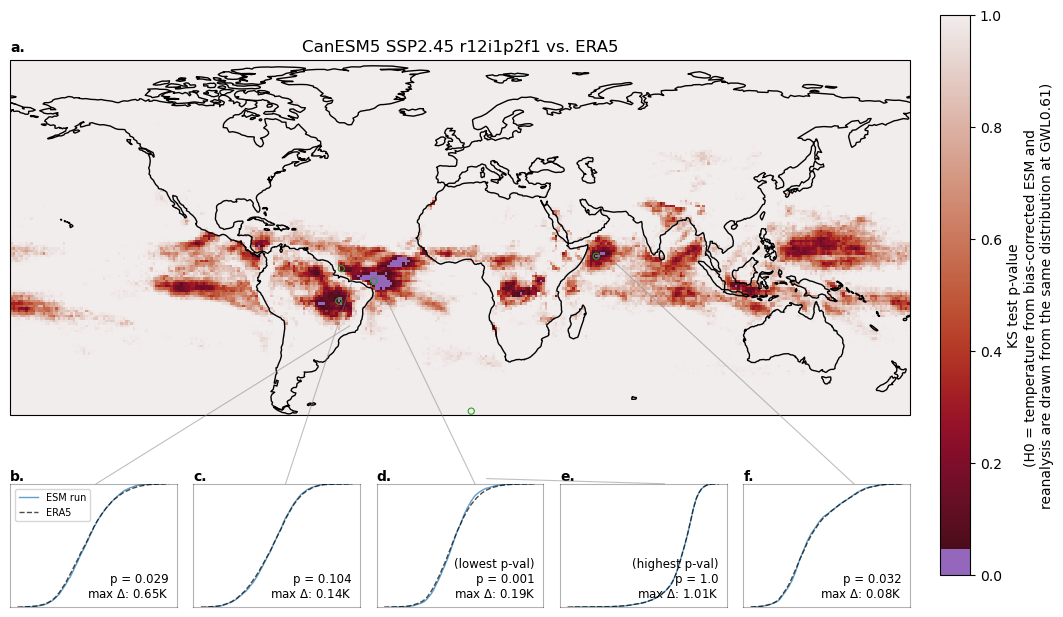

In [132]:
fig = plt.figure(figsize=(12,8))

cbar_params = {'vmin':0,'vmax':1,'cmap':cmap_mod}
clabel = 'KS test p-value\n(H0 = temperature from bias-corrected ESM and \nreanalysis are drawn from the same distribution at GWL0.61)'


save_fig = True
output_fn = f'{dir_list['aux']}diagnostics/cdf_figure_min_p_model'


low_p_N = 4

gs = mpl.gridspec.GridSpec(
    nrows=2,
    ncols=low_p_N+1,
    height_ratios=[4, 1],   # map dominates
    hspace=0,
    wspace=0.1
)

#----------------------
# Map figure
#----------------------
ax_map = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
pvals.plot(transform=ccrs.PlateCarree(),**cbar_params,add_colorbar=False)
ax_map.coastlines()

exp_str = str(lowest_fit_mod[1])
exp_str = exp_str.upper()
exp_str = exp_str[0:4]+'.'+exp_str[4:None]
ax_map.set_title(f'{lowest_fit_mod[0]} {exp_str} {lowest_fit_mod[2]} vs. {re.sub(r'\-025','',params_proc['mod_rea'])}')

ax_map.annotate(string.ascii_lowercase[0]+'.',(0,1.025),xycoords = 'axes fraction',
                fontweight='bold')

#----------------------
# Setup for CDFs
#----------------------
# Lowest p-value point
lowest_p_sample = pvals.where(pvals == pvals.min()).stack(locv=['lat','lon']).dropna('locv').isel(locv=[0])
# Samples from low p-values
thresh = 0.2#pvals.quantile(0.05)
low_p_sample = pvals.where(pvals<thresh).stack(locv=['lat','lon']).dropna('locv')
low_p_sample = low_p_sample.isel(locv = np.random.randint(0,low_p_sample.sizes['locv']-1,low_p_N-1))
# One sample high-pvalue point
highest_p_sample = pvals.where(pvals == pvals.max()).stack(locv=['lat','lon']).dropna('locv').isel(locv=[0])
samples = xr.concat([highest_p_sample,
                     low_p_sample,
                     lowest_p_sample],dim='locv')
# Sort in ascending lon order, for visual convenience
samples = samples.sortby('lon')


#----------------------
# CDF plots
#----------------------
axes_cdf = []

for i in range(low_p_N+1):
    ax = fig.add_subplot(gs[1, i])
    axes_cdf.append(ax)

    x1 = ds_mod[var].sel(lat=samples.isel(locv=i).lat, lon=samples.isel(locv=i).lon, gwl=0.61).values.flatten()
    x2 = ds_rea_tmp[var].sel(lat=samples.isel(locv=i).lat, lon=samples.isel(locv=i).lon).values.flatten()

    def ecdf(x):
        x = np.sort(x)
        y = np.arange(1, len(x) + 1) / len(x)
        return x, y

    x1s, y1 = ecdf(x1)
    x2s, y2 = ecdf(x2)

    ax.plot(x1s, y1, lw=1, alpha=0.7, label='ESM run',color='tab:blue')
    ax.plot(x2s, y2, lw=1, alpha=0.7, label=re.sub(r'\-025','',params_proc['mod_rea']),color='k',linestyle='--')

    # Add ks value 
    if samples.isel(locv=i) == samples.min():
        ann_text = '(lowest p-val)\n'
    elif samples.isel(locv=i) == samples.max():
        ann_text = '(highest p-val)\n'
    else:
        ann_text = ''
        
    ann_text = ann_text+f'p = {str(np.round(samples.isel(locv=i).values,3))}'
    ann_text = ann_text+'\n'+r'max $\Delta$: '+str(np.round(np.max(np.abs(x1s-x2s)),2))+'K'

    ax.annotate(ann_text,(0.95,0.05),xycoords='axes fraction',
                ha='right',va='bottom',fontsize=8.5)
        

    # Make minimalist
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_alpha(0.3)

    ax.annotate(string.ascii_lowercase[i+1]+'.',(0,1.025),xycoords = 'axes fraction',
                fontweight='bold')

#----------------------
# CDF connecting lines
#----------------------
for ax_cdf, lat, lon in zip(axes_cdf, samples.lat.values, samples.lon.values):

    # Map location in display coords
    x_map, y_map = ax_map.transData.transform((lon, lat))
    
    # Top-center of CDF axis in display coords
    bbox = ax_cdf.get_window_extent()
    x_cdf = 0.5 * (bbox.x0 + bbox.x1)
    y_cdf = bbox.y1

    # Convert both to figure coords
    x_map_f, y_map_f = fig.transFigure.inverted().transform((x_map, y_map))
    x_cdf_f, y_cdf_f = fig.transFigure.inverted().transform((x_cdf, y_cdf))

    line = mlines.Line2D(
        [x_map_f, x_cdf_f],
        [y_map_f, y_cdf_f],
        transform=fig.transFigure,
        color="0.5",
        lw=0.8,
        alpha=0.5,
        zorder=2
    )
    fig.add_artist(line)

axes_cdf[0].legend(fontsize=7)

# Add markers on the map
ax_map.scatter(
    samples.lon.values,
    samples.lat.values,
    s=20,facecolor='none',edgecolor='tab:green',
    lw=0.8,transform=ccrs.PlateCarree(),
    zorder=5
)


# Vertical colorbar
fig.subplots_adjust(right=0.875)
cax = fig.add_axes([0.9, 0.15, 0.025, 0.7])
if 'levels' in cbar_params:
    levels = mpl.ticker.MaxNLocator(nbins=cbar_params['levels']).tick_values(cbar_params['vmin'],cbar_params['vmax'])
    norm = mpl.colors.BoundaryNorm(levels, ncolors=cbar_params['cmap'].N, clip=True)
else:
    norm = mpl.colors.Normalize(vmin=cbar_params['vmin'],vmax=cbar_params['vmax'])
sm = plt.cm.ScalarMappable(cmap=cbar_params['cmap'],norm=norm)
plt.colorbar(sm,cax=cax,label=clabel)

if save_fig:
    utility_print(output_fn)